# Entrenamiento de Deep Q-Learning en Flappy Bird

Este notebook contiene el proceso de experimentación y entrenamiento de un agente DQN para resolver el entorno FlappyBird-v0. Implementamos *experience replay* y una red objetivo para estabilizar la aproximación de la función de valor. 

## 1. Preparación del entorno 

En esta sección configuramos el entorno de ejecución, instalamos las dependencias necesarias y aseguramos la reproducibilidad de los experimentos.

In [26]:
#!git clone https://github.com/rafelsalgueiro/GallegoSalgueiroVera.git

In [27]:
!pip install -q gymnasium flappy-bird-gymnasium torch numpy matplotlib seaborn pygame tqdm pandas

Después de la instalación, realizamos la importación de librerías y configuración.

In [ ]:
import os
import pickle
import sys
from collections import deque

import torch
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm

project_root = os.path.abspath('.')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.envs.flappy_bird import make_flappy_bird_env
from src.agents.td_agents_dqn import DQNAgent, DQNReplayBuffer
from src.plotting.plotting import (
    plot_robust_learning_curves, 
    plot_dqn_loss, plot_average_q_values, plot_rewards,
    plot_episode_lengths
)

print("Módulos importados con éxito.")

Módulos importados con éxito.


Continuamos con la creación de directorios para almacenar los modelos y resultados y la configuración del dispositivo.

In [29]:
MODELS_DIR = os.path.join(project_root, "models")
RESULTS_DIR = os.path.join(project_root, "results")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Configuración del dispositivo (GPU si está disponible, sino CPU)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo configurado para entrenamiento: {DEVICE.upper()}")

Dispositivo configurado para entrenamiento: CUDA


Finalmente, aseguramos la reproducibilidad de los experimentos.

In [30]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Semilla global fijada en: {seed}")

# Fijamos la semilla inicial
GLOBAL_SEED = 314159
set_seed(GLOBAL_SEED)

Semilla global fijada en: 314159


## 2. Diseño experimental y bucle de entrenamiento

En primer lugar, definimos el método que va a dar forma a todos los entrenamientos que hagamos. 


In [43]:
def train_dqn(env, agent, buffer, num_episodes, batch_size, min_memory, max_steps, strat_name, seed, models_dir):
    """
    Ejecuta el bucle de entrenamiento estándar de DQN con Model Checkpointing.
    Mantiene un log limpio mostrando el récord en la barra de tqdm 
    y reportando el progreso general solo cada 10% del entrenamiento.
    """
    history = {
        'rewards': [], 'lengths': [], 'losses': [], 'max_q_values': []
    }
    
    window_size = 30
    recent_rewards = deque(maxlen=window_size)
    
    best_window_score = -float('inf')
    best_episode = 0
    best_model_path = os.path.join(models_dir, f"best_{strat_name}_seed_{seed}.pth")

    # Calculamos el intervalo para el reporte del 10%
    milestone = num_episodes // 10

    pbar = tqdm(range(num_episodes), desc=f"Entrenando {strat_name} (Seed {seed})", leave=False)
    
    for ep in pbar:
        state, _ = env.reset()
        done = False
        ep_reward = 0
        ep_length = 0
        ep_losses = []
        ep_max_qs = []
        
        while not done:
            action = agent.get_action(state)
            ep_max_qs.append(np.max(agent.get_q_value(state)))
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            buffer.add(state, action, reward, next_state, done)

            if len(buffer) >= min_memory:
                states_b, actions_b, rewards_b, next_states_b, dones_b = buffer.sample(batch_size)
                loss = agent.train_step(states_b, actions_b, rewards_b, next_states_b, dones_b)
                ep_losses.append(loss)
                
            state = next_state
            ep_reward += reward
            ep_length += 1

            if ep_length >= max_steps:
                done = True
            
        agent.decay_epsilon()
        
        ep_mean_q = np.mean(ep_max_qs) if ep_max_qs else 0.0
        
        history['rewards'].append(ep_reward)
        history['lengths'].append(ep_length)
        history['losses'].append(np.mean(ep_losses) if ep_losses else 0.0)
        history['max_q_values'].append(ep_mean_q)
        
        # --- LÓGICA DE CHECKPOINTING Y TQDM ---
        if len(buffer) >= min_memory:
            recent_rewards.append(ep_reward)
            
            if len(recent_rewards) == window_size:
                current_mean = np.mean(recent_rewards)
                
                if current_mean > best_window_score:
                    best_window_score = current_mean
                    best_episode = ep
                    
                    # Guardamos el modelo silenciosamente en disco
                    agent.save_weights(best_model_path)
                    
                    # Mantenemos la información siempre visible a la derecha de la barra
                    pbar.set_postfix({
                        "Récord": f"{best_window_score:.2f}",
                        "Ep": best_episode
                    })

        # --- REPORTE DEL 10% ---
        if milestone > 0 and ep > 0 and ep % milestone == 0:
            porcentaje = int((ep / num_episodes) * 100)
            if best_window_score != -float('inf'):
                pbar.write(f"📈 [{porcentaje}%] Progreso general | Mejor media actual: {best_window_score:.2f} (lograda en el episodio {best_episode})")
            else:
                pbar.write(f"📈 [{porcentaje}%] Progreso general | (Llenando memoria, sin récord aún)")
    
    # Auto-restauración al finalizar todos los episodios
    if os.path.exists(best_model_path):
        agent.load_weights(best_model_path)
        
    return history

Para determinar la estrategia de aprendizaje más robusta y eficiente, estableceremos un marco de evaluación justo aislando dos componentes críticos: el uso de una **Red Objetivo (Target Network)** para la estabilidad del aprendizaje, y la aplicación de **Reward Shaping** para guiar la exploración temprana del agente.

El *Reward Shaping* se controla mediante el parámetro $\alpha$, que otorga una bonificación proporcional a la cercanía del agente al centro del hueco entre las tuberías. Evaluaremos cinco configuraciones distintas. Para garantizar la validez estadística y mitigar la alta varianza inherente al Aprendizaje por Refuerzo Profundo, cada estrategia se entrenará desde cero utilizando **3 semillas aleatorias diferentes** durante **2000 episodios**.

### Configuraciones a Evaluar

| ID | Nombre de la Estrategia | Target Network | Reward Shaping ($\alpha$) | Descripción y Objetivo del Experimento |
| :--- | :--- | :---: | :---: | :--- |
| **A** | Vanilla DQN (Sin Target) | No | 0.0 | **Línea base pura:** DQN original propuesto en 2013. Se espera alta inestabilidad y sobreestimación catastrófica. |
| **B** | DQN Estándar | Sí | 0.0 | **Línea base moderna:** DQN con red objetivo. Solo aprende de las recompensas nativas (sobrevivir y cruzar). |
| **C** | DQN + Shaping ligero | Sí | 0.05 | **Heurística anecdótica:** DQN con red objetivo. Bonificación menor a la recompensa por supervivencia. |
| **D** | DQN + Shaping Moderado | Sí | 0.25 | **Heurística de apoyo:** Bonificación suave por centrarse. Busca acelerar la convergencia sin dominar la recompensa de cruzar el tubo. |
| **E** | DQN + Shaping Agresivo | Sí | 0.50 | **Heurística estricta:** Alta bonificación por centrarse. Evalúa el riesgo de *Reward Hacking* o políticas subóptimas. |

Todos los demás hiperparámetros (arquitectura de la red, capacidad de memoria, decaimiento de exploración, tasa de aprendizaje, etc.) se mantendrán constantes entre los cuatro grupos.

In [32]:
NUM_EPISODES = 2000
NUM_SEEDS = 3
SEEDS = [GLOBAL_SEED, GLOBAL_SEED+1, GLOBAL_SEED+2]
# Parámetros del Replay Buffer
BUFFER_CAPACITY = 10000
MIN_MEMORY = 1000
BATCH_SIZE = 64

# Parámetros de la Red Neuronal y Optimizador
HIDDEN_DIM = 128
LEARNING_RATE = 1e-3
GAMMA = 0.99
GRAD_CLIP = 1.0

# Parámetros de Exploración (Epsilon-Greedy)
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.996

# Parámetros de la Red Objetivo (cuando se usa)
TARGET_UPDATE_FREQ = 500
DOUBLE_DQN = False # Mantenemos en False por ahora para aislar el efecto de Target Net y Shaping

# Límite de pasos por episodio
MAX_STEPS_PER_EPISODE = 2000 

experiments_config = {
    "A_Vanilla_DQN": {
        "alpha": 0.0,
        "use_target_network": False
    },
    "B_DQN_Standard": {
        "alpha": 0.0,
        "use_target_network": True
    },
    "C_DQN_Shaping_Lev": {
        "alpha": 0.05,
        "use_target_network": True
    },
    "D_DQN_Shaping_Mod": {
        "alpha": 0.25,
        "use_target_network": True
    },
    "E_DQN_Shaping_Agr": {
        "alpha": 0.50,
        "use_target_network": True
    }
}

print(f"Configurados {len(experiments_config)} experimentos. "
      f"Entrenamientos totales a ejecutar: {len(experiments_config) * NUM_SEEDS} "
      f"({NUM_EPISODES} episodios por entrenamiento).")

Configurados 5 experimentos. Entrenamientos totales a ejecutar: 15 (2000 episodios por entrenamiento).


## 3. Entrenamiento exploratorio y evaluación

En esta fase, ejecutaremos la batería de experimentos diseñada. Para garantizar una comparativa rigurosa, cada estrategia será entrenada desde cero a través de múltiples semillas aleatorias, lo que nos permitirá evaluar tanto su rendimiento promedio como su estabilidad (varianza).

El proceso de evaluación consta de dos pilares para cada semilla:
1. **Fase de Entrenamiento (Tendencia y Potencial):** Entrenaremos al agente durante 2000 episodios, registrando su recompensa acumulada, longitud del episodio, pérdida (Loss) y Valores Q. Esto nos mostrará la curva de aprendizaje y si el agente tiene una tendencia de mejora continua o si se estanca prematuramente.
2. **Fase de Evaluación Greedy (Rendimiento Real):** Inmediatamente después del entrenamiento, "congelaremos" el aprendizaje del agente y anularemos su tasa de exploración ($\epsilon = 0.0$). Lo someteremos a **100 episodios de prueba** donde actuará de forma totalmente determinista (explotación pura). En esta fase ignoraremos las recompensas modificadas (*shaping*) y mediremos únicamente la **puntuación real del juego** (número de tuberías cruzadas exitosamente).

Esta métrica final, agregada a lo largo de todas las semillas, nos proporcionará una distribución de datos pura sobre la que calcularemos la media, mediana y desviación típica, y que visualizaremos posteriormente mediante diagramas de caja (*boxplots*).

In [33]:
training_curves = {
    strat: {'rewards': [], 'lengths': [], 'losses': [], 'max_qs': []} 
    for strat in experiments_config.keys()
    }

evaluation_scores = {strat: [] for strat in experiments_config.keys()}

NUM_EVAL_EPISODES = 100

print("Iniciando experimentos\n")

for strat_name, strat_params in experiments_config.items():
    print(f"{'='*60}\nEstrategia: {strat_name} | Alpha: {strat_params['alpha']} | Target: {strat_params['use_target_network']}\n{'='*60}")
    
    strat_alpha = strat_params['alpha']
    use_target = strat_params['use_target_network']
    
    for seed_idx, seed in enumerate(SEEDS):
        print(f"\nSemilla {seed_idx + 1}/{NUM_SEEDS} ({seed})")
        set_seed(seed)
        
        # Instanciar Entorno y Agente específicos para esta ejecución
        env = make_flappy_bird_env(alpha=strat_alpha)
        buffer = DQNReplayBuffer(BUFFER_CAPACITY, env.observation_space.shape[0])
        agent = DQNAgent(
            env=env, alpha=LEARNING_RATE, gamma=GAMMA, 
            epsilon_start=EPSILON_START, epsilon_min=EPSILON_MIN, epsilon_decay=EPSILON_DECAY, 
            hidden_dim=HIDDEN_DIM, use_target_network=use_target, target_update_freq=TARGET_UPDATE_FREQ, 
            device=DEVICE
        )
        
        # Fase de Entrenamiento
        history = train_dqn(
            env, agent, buffer, NUM_EPISODES, BATCH_SIZE, MIN_MEMORY, MAX_STEPS_PER_EPISODE,
            strat_name=strat_name, seed=seed, models_dir=MODELS_DIR
        )

        training_curves[strat_name]['rewards'].append(history['rewards'])
        training_curves[strat_name]['lengths'].append(history['lengths'])
        training_curves[strat_name]['losses'].append(history['losses'])
        training_curves[strat_name]['max_qs'].append(history['max_q_values'])
        
        # Fase de evaluación greedy
        agent.epsilon = 0.0
        seed_eval_scores = []
        
        for _ in range(NUM_EVAL_EPISODES):
            state, _ = env.reset()
            done = False
            score = 0
            step_count = 0
            while not done and step_count < MAX_STEPS_PER_EPISODE:
                action = agent.get_action(state)
                state, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated
                score = info.get('score', score)
                step_count += 1
            seed_eval_scores.append(score)
            
        evaluation_scores[strat_name].extend(seed_eval_scores)
        print(f"   Evaluación finalizada. Score Promedio: {np.mean(seed_eval_scores):.2f} tuberías.")

    # Convertir las listas de historiales a matrices NumPy (num_seeds, num_episodes) para facilitar el plotteo robusto
    for metric in training_curves[strat_name]:
        training_curves[strat_name][metric] = np.array(training_curves[strat_name][metric])

# Guardado de Seguridad de todos los resultados en disco
with open(os.path.join(RESULTS_DIR, 'training_curves.pkl'), 'wb') as f:
    pickle.dump(training_curves, f)
with open(os.path.join(RESULTS_DIR, 'evaluation_scores.pkl'), 'wb') as f:
    pickle.dump(evaluation_scores, f)

print("\nTodos los experimentos han finalizado y los datos han sido guardados en 'results/'.")

Iniciando experimentos

Estrategia: A_Vanilla_DQN | Alpha: 0.0 | Target: False

Semilla 1/3 (314159)
Semilla global fijada en: 314159


   Evaluación finalizada. Score Promedio: 0.03 tuberías.

Semilla 2/3 (314160)
Semilla global fijada en: 314160


   Evaluación finalizada. Score Promedio: 1.83 tuberías.

Semilla 3/3 (314161)
Semilla global fijada en: 314161


   Evaluación finalizada. Score Promedio: 2.39 tuberías.
Estrategia: B_DQN_Standard | Alpha: 0.0 | Target: True

Semilla 1/3 (314159)
Semilla global fijada en: 314159


   Evaluación finalizada. Score Promedio: 2.10 tuberías.

Semilla 2/3 (314160)
Semilla global fijada en: 314160


...

   Evaluación finalizada. Score Promedio: 3.29 tuberías.

Semilla 3/3 (314161)
Semilla global fijada en: 314161


   Evaluación finalizada. Score Promedio: 2.03 tuberías.
Estrategia: E_DQN_Shaping_Agr | Alpha: 0.5 | Target: True

Semilla 1/3 (314159)
Semilla global fijada en: 314159


   Evaluación finalizada. Score Promedio: 0.99 tuberías.

Semilla 2/3 (314160)
Semilla global fijada en: 314160


   Evaluación finalizada. Score Promedio: 1.61 tuberías.

Semilla 3/3 (314161)
Semilla global fijada en: 314161


   Evaluación finalizada. Score Promedio: 2.59 tuberías.

Todos los experimentos han finalizado y los datos han sido guardados en 'results/'.


Generando Curvas de Aprendizaje...


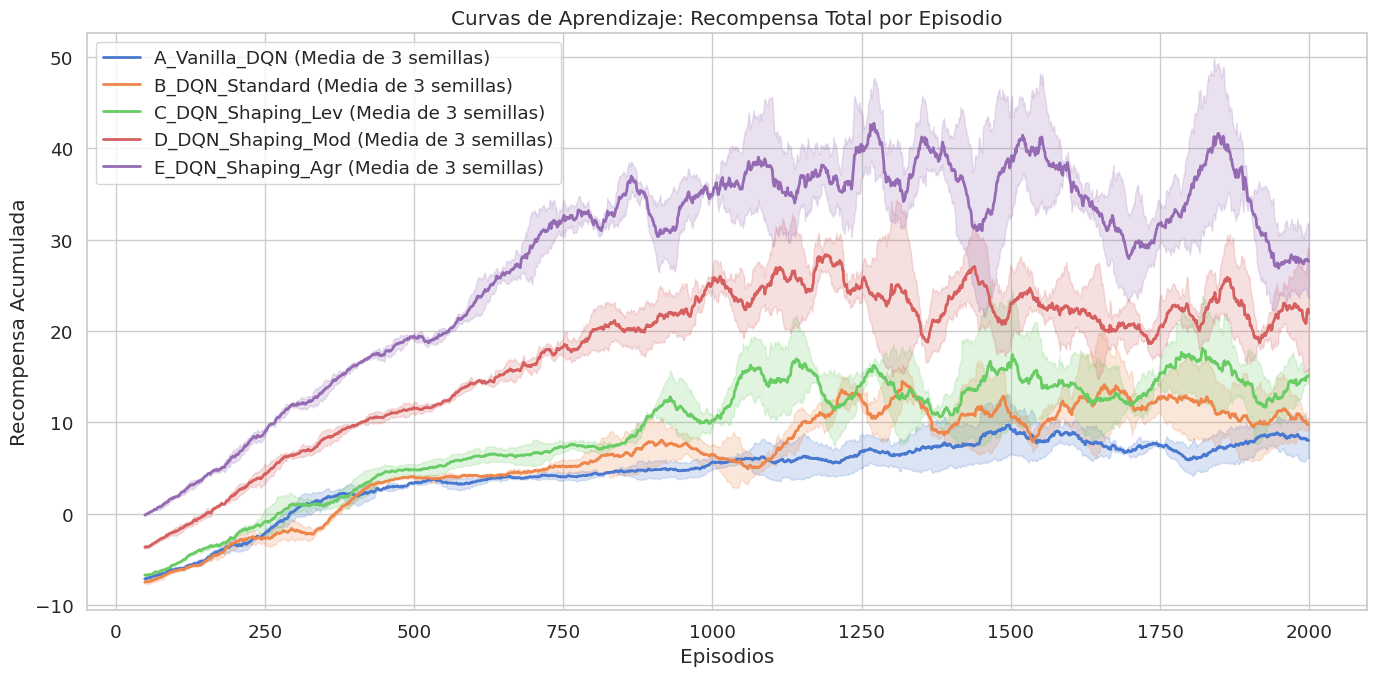

Generando Evolución de Valores Q...


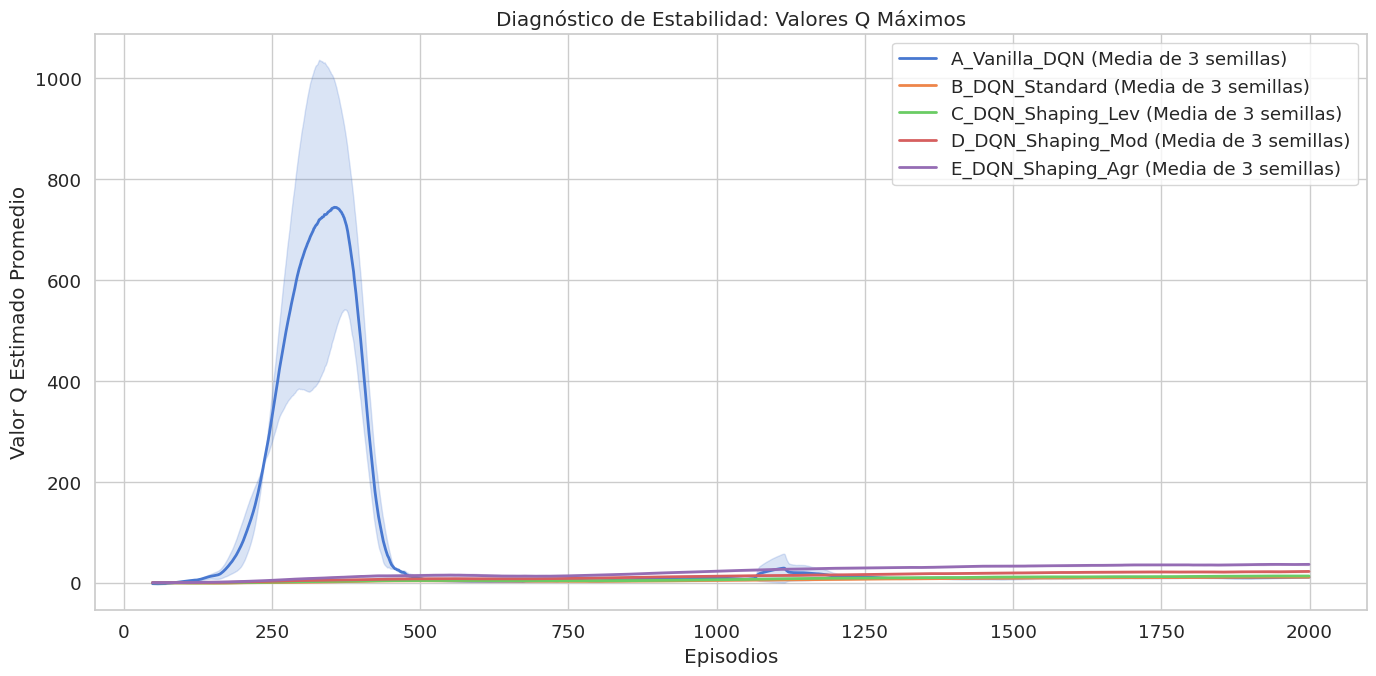

Generando Distribución de Evaluación Final...


/tmp/ipykernel_535571/535402184.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


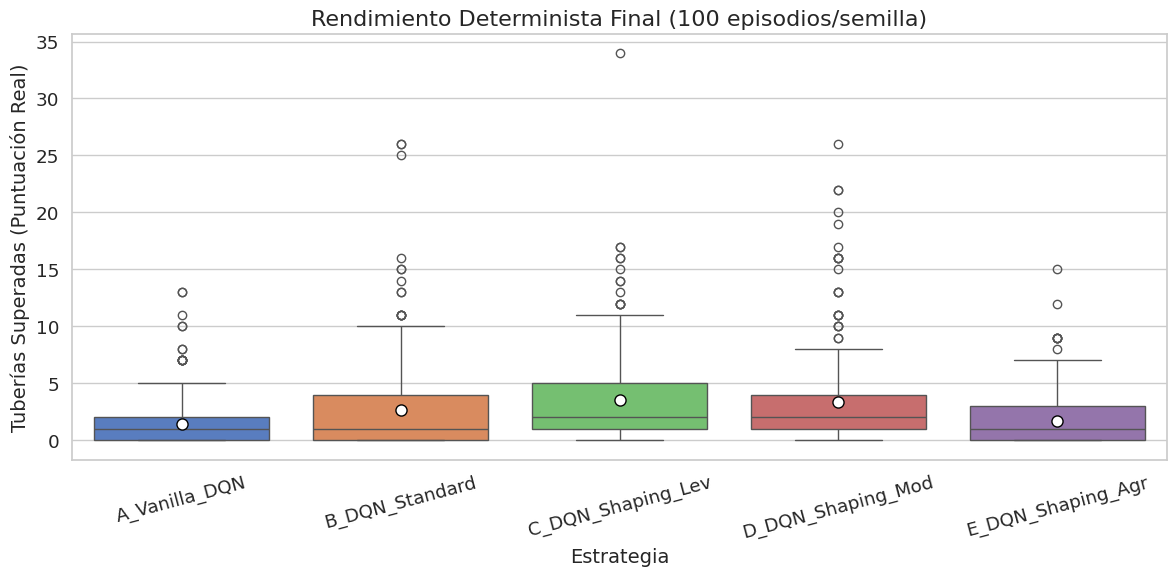


Resumen Estadístico del Rendimiento Real:


,Media,Mediana,Desv_Tipica,Maximo
Estrategia,,,,
C_DQN_Shaping_Lev,3.573333,2.0,3.934831,34
D_DQN_Shaping_Mod,3.340000,2.0,4.033853,26
B_DQN_Standard,2.626667,1.0,3.960586,26
E_DQN_Shaping_Agr,1.730000,1.0,2.245121,15
A_Vanilla_DQN,1.416667,1.0,2.073012,13


In [34]:
dict_rewards = {strat: data['rewards'] for strat, data in training_curves.items()}
dict_max_qs = {strat: data['max_qs'] for strat, data in training_curves.items()}

print("Generando Curvas de Aprendizaje...")
plot_robust_learning_curves(
    data_dict=dict_rewards, 
    window_size=50, 
    title="Curvas de Aprendizaje: Recompensa Total por Episodio", 
    ylabel="Recompensa Acumulada"
)

print("Generando Evolución de Valores Q...")
plot_robust_learning_curves(
    data_dict=dict_max_qs, 
    window_size=50, 
    title="Diagnóstico de Estabilidad: Valores Q Máximos", 
    ylabel="Valor Q Estimado Promedio"
)

print("Generando Distribución de Evaluación Final...")

eval_data_list = []
for strat, scores in evaluation_scores.items():
    for score in scores:
        eval_data_list.append({"Estrategia": strat, "Tuberías Superadas": score})

df_eval = pd.DataFrame(eval_data_list)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_eval, 
    x="Estrategia", 
    y="Tuberías Superadas", 
    palette="muted", 
    showmeans=True, 
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)
plt.title("Rendimiento Determinista Final (100 episodios/semilla)", fontsize=16)
plt.xlabel("Estrategia", fontsize=14)
plt.ylabel("Tuberías Superadas (Puntuación Real)", fontsize=14)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nResumen Estadístico del Rendimiento Real:")
display(df_eval.groupby("Estrategia").agg(
    Media=('Tuberías Superadas', 'mean'),
    Mediana=('Tuberías Superadas', 'median'),
    Desv_Tipica=('Tuberías Superadas', 'std'),
    Maximo=('Tuberías Superadas', 'max')
).sort_values(by="Media", ascending=False))

El análisis cruzado de las curvas de aprendizaje (recompensa interna) y el rendimiento determinista final (tuberías superadas) revela conclusiones fundamentales sobre la dinámica de aprendizaje en DQN y el impacto del *Reward Shaping*.

- Necesidad de *target network*: la **Estrategia A (Vanilla DQN)** demuestra empíricamente por qué la arquitectura original de 2013 requería estabilización. Si observamos la gráfica de *Diagnóstico de Estabilidad*, los Valores Q de la Estrategia A sufren una **sobreestimación catastrófica**, disparándose por encima de 1000 alrededor del episodio 300, para luego colapsar por completo. Al actualizar la red que estima el valor con sus propias predicciones en constante cambio, el agente entra en un bucle de retroalimentación positiva irreal. Esto se traduce en el peor rendimiento real de la tabla (media de 1.41 tuberías).

- Diferente escala de recompensas: la **Estrategia E (Shaping Agresivo, $\alpha=0.50$)** ilustra perfectamente el fenómeno del *Reward Hacking* (pirateo de recompensas). En la gráfica de curvas de aprendizaje, esta estrategia parece ser la campeona indiscutible, alcanzando recompensas acumuladas cercanas a 40. Sin embargo, su evaluación final determinista es paupérrima (media de 1.73 tuberías). El agente descubrió que mantenerse perfectamente centrado otorgaba tantos puntos que maximizó esa sub-tarea ignorando el objetivo principal. Aprendió a volar recto cobrando su bonus constante, estrellándose predeciblemente contra los bordes de las tuberías al no anticipar los saltos necesarios.

- Funcionamiento de la heurística: la **Estrategia C (Shaping Leve, $\alpha=0.05$)** se corona como la configuración óptima. Proporciona suficientes "migas de pan" durante los primeros compases del entrenamiento para evitar que el agente muera por puro azar, pero la bonificación es tan sutil que no eclipsa la recompensa nativa de cruzar una tubería (+1.0). Consigue la **mejor media (3.57)**, la **mejor mediana (2.0)** y el **récord absoluto de supervivencia (34 tuberías)** en un solo episodio.

Para poder apreciar la estabilidad del resto de modelos sin que el pico de la **Estrategia A (Vanilla DQN)** fuerce una escala desproporcionada volvemos a mostrar la gráfica de valores Q sin esta.

Generando Evolución de Valores Q (Sin Vanilla DQN)...


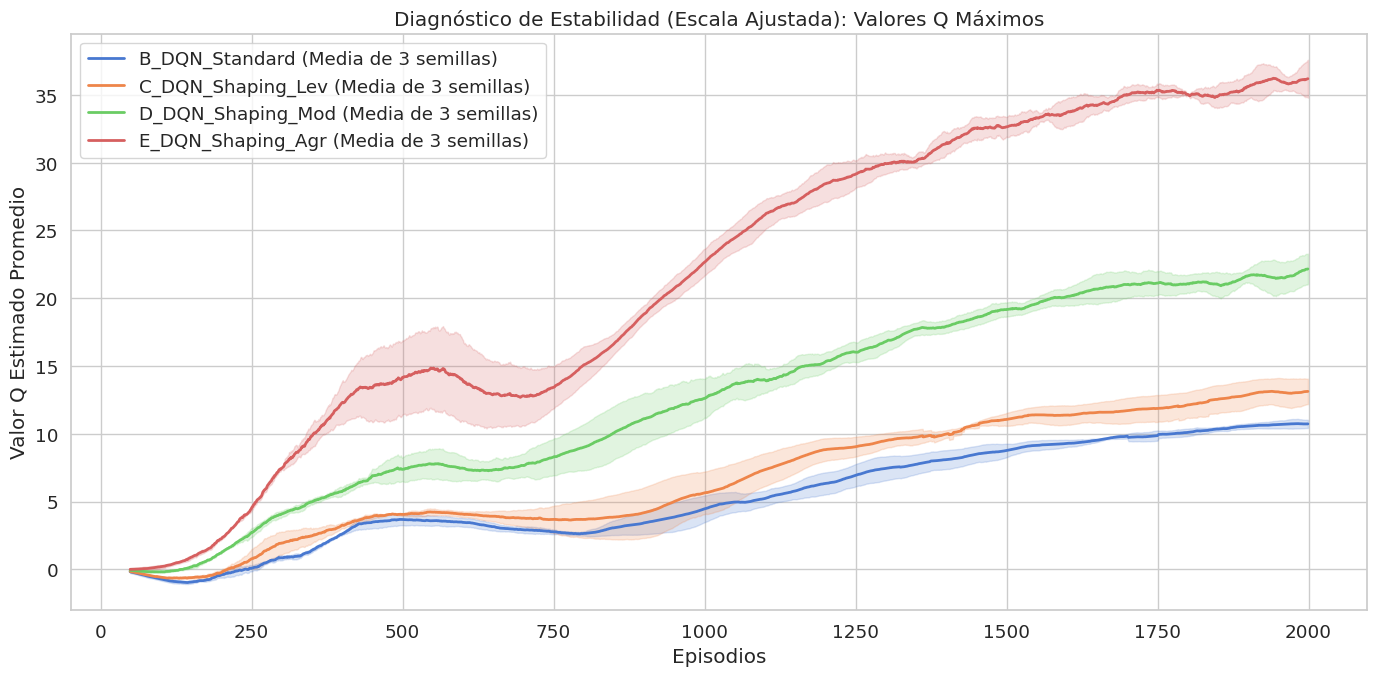

In [35]:
dict_max_qs_filtered = {
    strat: qs for strat, qs in dict_max_qs.items() if strat != "A_Vanilla_DQN"
}

print("Generando Evolución de Valores Q (Sin Vanilla DQN)...")
plot_robust_learning_curves(
    data_dict=dict_max_qs_filtered, 
    window_size=50, 
    title="Diagnóstico de Estabilidad (Escala Ajustada): Valores Q Máximos", 
    ylabel="Valor Q Estimado Promedio"
)

Al retirar la Estrategia A para observar la escala real del resto de agentes en el *Diagnóstico de Estabilidad Ajustado*, descubrimos el mecanismo interno del *Reward Hacking*. Las estrategias con *shaping* alto (D y E) muestran estimaciones de Valor Q que crecen de forma lineal y desproporcionada. La red neuronal infla el valor de los estados al acumular constantemente el bonus por mantenerse en el centro, perdiendo la noción de la recompensa nativa del juego. 

En contraste, la **Estrategia C (Shaping Leve)** mantiene sus Valores Q acotados y estables, demostrando que utiliza la heurística como apoyo inicial sin dejar que corrompa la estimación de la recompensa real.

## 4. Entrenamiento extendido

Habiendo identificado a la **Estrategia C (DQN + Shaping Leve, alpha=0.05)** como la arquitectura más robusta y prometedora, procederemos a un entrenamiento extendido del mismo. 

Observando sus curvas de aprendizaje, el rendimiento sigue una clara tendencia ascendente en el episodio 2000, lo que indica que el agente no ha convergido y tiene margen de mejora. Para explotar este potencial, ajustaremos los hiperparámetros hacia un enfoque de aprendizaje profundo a largo plazo:

* **Más Episodios (10,000):** Damos tiempo suficiente para que la red converja en una política óptima.
* **Exploración Prolongada (Epsilon Decay = 0.999):** Al jugar partidas más largas, el agente descubrirá configuraciones de tuberías más complejas en etapas avanzadas. Un decaimiento lento asegura que siga explorando estas nuevas situaciones en lugar de explotar una política prematura.
* **Mayor Memoria (Buffer Capacity = 50,000):** Un agente que sobrevive más tiempo genera muchas más transiciones. Aumentar el buffer evita que sobrescriba experiencias valiosas demasiado rápido, mejorando la estabilidad del *Experience Replay*.
* **Tasa de Aprendizaje Reducida (LR = 5e-4):** Reducimos ligeramente el paso del optimizador para "afinar" los pesos de la red (*fine-tuning*) sin dar saltos bruscos que puedan desestabilizar la política ya adquirida.

In [ ]:
HERO_EPISODES = 10000
HERO_ALPHA = 0.05
HERO_SEED = 42 # Fijamos una semilla única para el Hero Run

HERO_BUFFER_CAPACITY = 50000 # Mayor memoria
HERO_EPSILON_DECAY = 0.999   # Exploración más prolongada
HERO_LEARNING_RATE = 5e-4    # Fine-tuning más suave

print(f"🚀 Iniciando Entrenamiento Extendido (Campeón) - {HERO_EPISODES} episodios...\n")

set_seed(HERO_SEED)

# Instanciamos el entorno y componentes
env_hero = make_flappy_bird_env(alpha=HERO_ALPHA)
buffer_hero = DQNReplayBuffer(HERO_BUFFER_CAPACITY, env_hero.observation_space.shape[0])

agent_hero = DQNAgent(
    env=env_hero, 
    alpha=HERO_LEARNING_RATE, 
    gamma=GAMMA, 
    epsilon_start=EPSILON_START, 
    epsilon_min=EPSILON_MIN, 
    epsilon_decay=HERO_EPSILON_DECAY, 
    hidden_dim=HIDDEN_DIM, 
    use_target_network=True, 
    target_update_freq=TARGET_UPDATE_FREQ, 
    device=DEVICE
)

# Ejecutamos el entrenamiento con Checkpointing
hero_history = train_dqn(
    env_hero, agent_hero, buffer_hero, 
    num_episodes=HERO_EPISODES, 
    batch_size=BATCH_SIZE, 
    min_memory=MIN_MEMORY, 
    max_steps=MAX_STEPS_PER_EPISODE,
    strat_name="HERO_C_Shaping_Lev", 
    seed=HERO_SEED, 
    models_dir=MODELS_DIR
)

# Evaluación Final del Campeón
print("\nEvaluando al Campeón Final...")
agent_hero.epsilon = 0.0
hero_eval_scores = []

for _ in range(NUM_EVAL_EPISODES):
    state, _ = env_hero.reset()
    done = False
    score = 0
    step_count = 0
    while not done and step_count < MAX_STEPS_PER_EPISODE:
        action = agent_hero.get_action(state)
        state, reward, terminated, truncated, info = env_hero.step(action)
        done = terminated or truncated
        score = info.get('score', score)
        step_count += 1
    hero_eval_scores.append(score)

print(f"🏅 Rendimiento del Campeón: Media = {np.mean(hero_eval_scores):.2f} | Máximo = {np.max(hero_eval_scores)} tuberías.")

# Visualización rápida de la curva del Hero Run
plot_rewards(
    hero_history['rewards'], 
    window_size=100, 
    title="Curva de Aprendizaje - Entrenamiento Extendido (Estrategia C)"
)

🚀 Iniciando Entrenamiento Extendido (Campeón) - 10000 episodios...

Semilla global fijada en: 42


Entrenando HERO_C_Shaping_Lev (Seed 42):  10%|█         | 1003/10000 [00:56<10:08, 14.79it/s, Récord=1.42, Ep=920]

📈 [10%] Progreso general | Mejor media actual: 1.42 (lograda en el episodio 920)


Entrenando HERO_C_Shaping_Lev (Seed 42):  20%|██        | 2003/10000 [02:06<09:52, 13.50it/s, Récord=5.65, Ep=1867]

📈 [20%] Progreso general | Mejor media actual: 5.65 (lograda en el episodio 1867)


Entrenando HERO_C_Shaping_Lev (Seed 42):  30%|███       | 3003/10000 [03:20<09:06, 12.81it/s, Récord=6.27, Ep=2905]

📈 [30%] Progreso general | Mejor media actual: 6.27 (lograda en el episodio 2905)


Entrenando HERO_C_Shaping_Lev (Seed 42):  40%|████      | 4002/10000 [04:43<10:10,  9.83it/s, Récord=10.06, Ep=3960]

📈 [40%] Progreso general | Mejor media actual: 10.06 (lograda en el episodio 3960)


Entrenando HERO_C_Shaping_Lev (Seed 42):  40%|████      | 4039/10000 [04:47<09:33, 10.40it/s, Récord=10.06, Ep=3960]

In [ ]:
from Entornos_Complejos.src.plotting.plotting import plot_episode_lengths


SMOOTH_WINDOW = 250 

plot_rewards(
    hero_history['rewards'], 
    window_size=SMOOTH_WINDOW, 
    title="Hero Run: Recompensa Acumulada (10,000 episodios)"
)

plot_episode_lengths(
    hero_history['lengths'], 
    window_size=SMOOTH_WINDOW, 
    title="Hero Run: Supervivencia (Frames por Episodio)"
)

# 3. Estabilidad a Largo Plazo (Valores Q)
# Usamos una ventana grande para ver la macrotendencia de las estimaciones
plot_average_q_values(
    hero_history['max_q_values'], 
    title="Hero Run: Estabilidad de Valores Q a Largo Plazo"
)

# 4. Convergencia del Optimizador (Loss)
# La pérdida en DQN suele ser muy ruidosa, usamos una ventana enorme
plot_dqn_loss(
    hero_history['losses'], 
    window_size=500, 
    title="Hero Run: Evolución de la Pérdida (Huber Loss)"
)

# 5. Histograma de Rendimiento Determinista
plt.figure(figsize=(12, 6))
# Aseguramos que los bins cubran desde 0 hasta el máximo score del campeón
max_hero_score = int(np.max(hero_eval_scores)) if len(hero_eval_scores) > 0 else 1
bins = range(0, max_hero_score + 2)

sns.histplot(
    hero_eval_scores, 
    bins=bins, 
    kde=True, 
    color="#9b59b6", 
    edgecolor="black", 
    alpha=0.7
)

# Líneas de referencia para media y mediana
mean_score = np.mean(hero_eval_scores)
median_score = np.median(hero_eval_scores)

plt.axvline(mean_score, color='red', linestyle='dashed', linewidth=2, label=f'Media: {mean_score:.2f}')
plt.axvline(median_score, color='green', linestyle='solid', linewidth=2, label=f'Mediana: {median_score:.2f}')

plt.title(f"Distribución del Rendimiento Real del Campeón ($\epsilon=0$)\nMáximo alcanzado: {max_hero_score} tuberías", fontsize=16)
plt.xlabel("Tuberías Superadas", fontsize=14)
plt.ylabel("Frecuencia (Número de Episodios)", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()